# DECIGO Fisher Forecast for a First-Order Phase Transition Signal

This notebook reproduces the DECIGO Fisher-matrix analysis for a stochastic gravitational-wave background generated by a first-order phase transition. The signal model includes sound-wave and turbulence contributions, and the Fisher analysis is performed for the two logarithmic parameters

$\theta = \left(\ln \alpha,\ \ln(\beta/H_*)\right)$ 

while holding the transition temperature $T_*$ and wall velocity $v_w$ fixed.

The notebook is organized as follows:

1. Define constants, detector noise, and gravitational-wave source model.
2. Choose DECIGO-band fiducial models.
3. Compute the signal-to-noise ratio and Fisher matrix.
4. Generate the spectrum, sensitivity, SNR-contour, and Fisher-ellipse figures.

## Core analysis functions

Here are the definitions of the reusable functions used throughout the DECIGO Fisher forecast: the cosmological normalization, DECIGO noise model, first-order phase-transition spectrum, SNR calculation, alpha calibration, and two-parameter Fisher matrix.



In [1]:
import numpy as np

# Cosmology constants
# ----------------------------
MPC_IN_M = 3.085677581491367e22
H0_KM_S_MPC = 67.4
H0_SI = (H0_KM_S_MPC * 1000.0) / MPC_IN_M  # s^-1
SH_PREFAC = 3.0 * H0_SI**2 / (10.0 * np.pi**2)  # S_h = SH_PREFAC * Omega / f^3



def sh_from_omega(f_hz, omega):
    """
    Convert the dimensionless gravitational-wave energy density spectrum
    Omega_GW(f) into the strain power spectral density S_h(f).

    The conversion used here is

        S_h(f) = [3 H0^2 / (10 pi^2)] * Omega_GW(f) / f^3,

    where H0 is expressed in SI units.

    Parameters
    ----------
    f_hz : array_like
        Frequency array in Hz.
    omega : array_like
        Dimensionless gravitational-wave energy density spectrum Omega_GW(f).

    Returns
    -------
    array_like
        Strain power spectral density S_h(f) in Hz^{-1}.
    """
    f = np.asarray(f_hz, dtype=float)
    return SH_PREFAC * np.asarray(omega, dtype=float) / (f**3)


# ----------------------------
# DECIGO noise PSD (Yagi & Seto analytic fit -> arXiv:1101.3940 )
# One-sided strain PSD S_n(f) [1/Hz] for a single effective Michelson
def psd_decigo_full(f_hz):
    """
    Evaluate the DECIGO one-sided strain-noise power spectral density.

    This function implements the analytic DECIGO noise fit used in the
    Fisher forecast. The returned quantity is the single-channel strain
    noise PSD S_n(f), with units of Hz^{-1}.

    The model includes three contributions:
        1. shot noise,
        2. radiation-pressure noise,
        3. acceleration noise.

    Parameters
    ----------
    f_hz : array_like
        Frequency array in Hz.

    Returns
    -------
    array_like
        DECIGO strain-noise power spectral density S_n(f) in Hz^{-1}.
    """
    f = np.asarray(f_hz, dtype=float)
    fp = 7.36  # Hz
    term_shot = 7.05e-48 * (1.0 + (f / fp)**2)
    term_radp = 4.8e-51 * (f / 1.0)**(-4.0) / (1.0 + (f / fp)**2)
    term_acc  = 5.33e-52 * (f / 1.0)**(-4.0)
    return term_shot + term_radp + term_acc

# ----------------------------
# PT spectrum: sound + turbulence (arXiv:1705.01783)
# ----------------------------
def omega_pt_weir_sw_turb(
    f_hz,
    *,
    alpha,
    beta_over_H,
    Tstar_GeV,
    vw,
    gstar=106.75,
    Uf=None,
    zp=6.9,
    Gamma=4.0/3.0,
    turb_fraction=0.05,
):
    def omega_pt_weir_sw_turb(
    f_hz,
    *,
    alpha,
    beta_over_H,
    Tstar_GeV,
    vw,
    gstar=106.75,
    Uf=None,
    zp=6.9,
    Gamma=4.0/3.0,
    turb_fraction=0.05,
): """
    Computes the stochastic gravitational-wave spectrum from a first-order
    phase transition using sound-wave and turbulence contributions.

    The function returns the total dimensionless spectrum

    Omega_GW(f) = Omega_sw(f) + Omega_turb(f),

    after converting from h^2 Omega_GW to Omega_GW using the value of h
    implied by H0_KM_S_MPC.

    The model uses the benchmark efficiency closure

    kappa_f = alpha / (0.73 + 0.083 sqrt(alpha) + alpha),

    and, unless Uf is supplied directly,

    Uf^2 = (3/4) * kappa_f * alpha / (1 + alpha).

    The turbulence efficiency is taken to be

    kappa_turb = turb_fraction * kappa_f.

    Parameters
    ----------
    f_hz : array_like
        Frequency array in Hz.
    alpha : float
        Phase-transition strength parameter.
    beta_over_H : float
        Inverse duration of the transition, beta/H_*.
    Tstar_GeV : float
        Transition temperature T_* in GeV.
    vw : float
        Bubble wall velocity. Must satisfy 0 < vw <= 1.
    gstar : float, optional
        Effective number of relativistic degrees of freedom. Default is 106.75.
    Uf : float or None, optional
        RMS fluid velocity. If None, the benchmark closure above is used.
    zp : float, optional
        Numerical factor entering the sound-wave peak frequency. Default is 6.9.
    Gamma : float, optional
        Adiabatic index. Default is 4/3.
    turb_fraction : float, optional
        Fraction of the bulk fluid efficiency assigned to turbulence.
        Default is 0.05.

    Returns
    -------
    array_like
        Total dimensionless gravitational-wave spectrum Omega_GW(f).

    Raises
    ------
    ValueError
        Raised if alpha, beta_over_H, or Tstar_GeV are non-positive, or if
        vw is outside the interval 0 < vw <= 1.
    """
    
    f = np.asarray(f_hz, dtype=float)
    if not (alpha > 0 and beta_over_H > 0 and Tstar_GeV > 0 and 0 < vw <= 1):
        raise ValueError("Unphysical phase-transition parameters.")

    H_over_beta = 1.0 / beta_over_H

    # Efficiency closure (benchmark)
    kappa_f = alpha / (0.73 + 0.083 * np.sqrt(alpha) + alpha)
    if Uf is None:
        Uf2 = (3.0 / 4.0) * (kappa_f * alpha / (1.0 + alpha))
        Uf = float(np.sqrt(max(Uf2, 0.0)))
    kappa_turb = turb_fraction * kappa_f

    # Sound-wave characteristic frequency + shape
    f_sw = 8.9e-6 * (beta_over_H / vw) * (zp / 10.0) * (Tstar_GeV / 100.0) * (gstar / 100.0)**(1.0/6.0)
    x = f / f_sw
    S_sw = (x**3) * (7.0 / (4.0 + 3.0 * x**2))**(7.0/2.0)

    h2Omega_sw = (
        8.5e-6
        * (100.0 / gstar)**(1.0/3.0)
        * (Gamma**2)
        * (Uf**4)
        * H_over_beta
        * vw
        * S_sw
    )

    # Turbulence characteristic frequency + shape
    f_turb = 27.0e-6 * (beta_over_H / vw) * (Tstar_GeV / 100.0) * (gstar / 100.0)**(1.0/6.0)
    h_star = 16.5e-6 * (Tstar_GeV / 100.0) * (gstar / 100.0)**(1.0/6.0)

    y = f / f_turb
    S_turb = (y**3) / ((1.0 + y)**(11.0/3.0) * (1.0 + 8.0*np.pi*f/h_star))

    h2Omega_turb = (
        3.35e-4
        * H_over_beta
        * (kappa_turb * alpha / (1.0 + alpha))**(3.0/2.0)
        * (100.0 / gstar)**(1.0/3.0)
        * vw
        * S_turb
    )

    # Convert h^2 Omega -> Omega
    h = H0_KM_S_MPC / 100.0
    return (h2Omega_sw + h2Omega_turb) / (h**2)

def omega_pt_lnparams(f_hz, ln_alpha, ln_beta_over_H, ln_Tstar, ln_vw, **kwargs):
    """
    Evaluate the phase-transition spectrum using logarithmic parameters.

    This wrapper is used in the Fisher calculation, where finite-difference
    derivatives are taken with respect to logarithmic parameters. The physical
    parameters are recovered through

        alpha      = exp(ln_alpha),
        beta/H_*   = exp(ln_beta_over_H),
        T_*        = exp(ln_Tstar),
        v_w        = exp(ln_vw).

    Parameters
    ----------
    f_hz : array_like
        Frequency array in Hz.
    ln_alpha : float
        Natural logarithm of the phase-transition strength alpha.
    ln_beta_over_H : float
        Natural logarithm of beta/H_*.
    ln_Tstar : float
        Natural logarithm of the transition temperature T_* in GeV.
    ln_vw : float
        Natural logarithm of the bubble wall velocity v_w.
    **kwargs
        Additional keyword arguments passed to omega_pt_weir_sw_turb.

    Returns
    -------
    array_like
        Total dimensionless gravitational-wave spectrum Omega_GW(f).
    """
    return omega_pt_weir_sw_turb(
        f_hz,
        alpha=float(np.exp(ln_alpha)),
        beta_over_H=float(np.exp(ln_beta_over_H)),
        Tstar_GeV=float(np.exp(ln_Tstar)),
        vw=float(np.exp(ln_vw)),
        **kwargs
    )

# ----------------------------
# Peak finder (numerical peak of total Omega_GW)
# ----------------------------
def find_peak_frequency(omega_func, fmin=1e-4, fmax=1e2, n=30000):
    """
    Find the numerical peak of a gravitational-wave spectrum.

    The function samples omega_func on a logarithmically spaced frequency grid
    and returns the frequency at which the spectrum is largest.

    Parameters
    ----------
    omega_func : callable
        Function that takes a frequency array in Hz and returns Omega_GW(f).
    fmin : float, optional
        Minimum frequency in Hz used in the peak search.
    fmax : float, optional
        Maximum frequency in Hz used in the peak search.
    n : int, optional
        Number of logarithmically spaced frequency samples.

    Returns
    -------
    f_peak : float
        Frequency in Hz where Omega_GW(f) reaches its maximum on the sampled grid.
    omega_peak : float
        Value of Omega_GW(f) at the numerical peak.
    """
    f = np.logspace(np.log10(fmin), np.log10(fmax), int(n))
    om = np.asarray(omega_func(f), dtype=float)
    i = int(np.argmax(om))
    return float(f[i]), float(om[i])
# ----------------------------
# DECIGO cross-correlation SNR (gamma=1 default)
def snr_decigo_crosscorr_from_params(
    *,
    alpha,
    beta_over_H,
    Tstar_GeV,
    vw,
    T_obs_yr=4.0,
    fmin=0.01,
    fmax=100.0,
    nfreq=200000,
    n_channels=2,
    gamma_func=None,
    # PT kwargs
    gstar=106.75,
    Uf=None,
    zp=6.9,
    Gamma=4.0/3.0,
    turb_fraction=0.05,
):
    """
    Compute the DECIGO cross-correlation signal-to-noise ratio.

    The SNR is computed using

    rho^2 = 2 T_obs n_channels $\int$ df gamma^2(f) S_h^2(f) / P^2(f),

    where S_h(f) is the strain power spectral density corresponding to
    Omega_GW(f), P(f) is the DECIGO single-channel strain-noise PSD, and
    gamma(f) is the overlap reduction function. By default gamma(f)=1,
    corresponding to the optimistic co-located/co-aligned limit used in this
    forecast.

    Parameters
    ----------
    alpha : float
        Phase-transition strength parameter.
    beta_over_H : float
        Inverse duration of the transition, beta/H_*.
    Tstar_GeV : float
        Transition temperature T_* in GeV.
    vw : float
        Bubble wall velocity.
    T_obs_yr : float, optional
        Observation time in years. Default is 4 years.
    fmin, fmax : float, optional
        Lower and upper limits of the frequency integral in Hz.
    nfreq : int, optional
        Number of logarithmically spaced frequency samples used in the integral.
    n_channels : int, optional
        Number of independent DECIGO channel pairs included in the SNR.
        Default is 2.
    gamma_func : callable or None, optional
        Function returning gamma(f). If None, gamma(f)=1 is used.
    gstar, Uf, zp, Gamma, turb_fraction : optional
        Source-model parameters passed to omega_pt_weir_sw_turb.

    Returns
    -------
    float
        Cross-correlation signal-to-noise ratio rho.
    """
    f = np.logspace(np.log10(fmin), np.log10(fmax), int(nfreq))
    gamma = np.ones_like(f) if gamma_func is None else np.asarray(gamma_func(f), dtype=float)

    omega = omega_pt_weir_sw_turb(
        f,
        alpha=float(alpha),
        beta_over_H=float(beta_over_H),
        Tstar_GeV=float(Tstar_GeV),
        vw=float(vw),
        gstar=gstar, Uf=Uf, zp=zp, Gamma=Gamma, turb_fraction=turb_fraction
    )
    omega = np.clip(omega, 0.0, np.inf)
    Sh = sh_from_omega(f, omega)

    P = psd_decigo_full(f)
    weight = (gamma**2) / (P * P)

    T_obs_sec = T_obs_yr * 365.25 * 24.0 * 3600.0
    snr2 = (2.0 * T_obs_sec) * np.trapezoid(weight * (Sh**2), f) * float(n_channels)
    return float(np.sqrt(max(snr2, 0.0)))

# ----------------------------
# Solve alpha for target SNR 
def solve_alpha_for_target_rho_decigo(
    *,
    rho_target,
    beta_over_H,
    Tstar_GeV,
    vw,
    alpha_lo=1e-6,
    alpha_hi=3.0,
    tol=1e-3,
    max_iter=80,
    **snr_kwargs,
):
    """
    Solve for the value of alpha that gives a target DECIGO SNR.

    For fixed beta/H_*, T_*, and v_w, this function varies only the
    phase-transition strength alpha. The root-finding is done by bisection in
    log(alpha), using the geometric midpoint between the current lower and
    upper bounds.

    Parameters
    ----------
    rho_target : float
        Desired signal-to-noise ratio.
    beta_over_H : float
        Fixed inverse duration beta/H_*.
    Tstar_GeV : float
        Fixed transition temperature T_* in GeV.
    vw : float
        Fixed bubble wall velocity.
    alpha_lo, alpha_hi : float, optional
        Lower and upper bounds for the alpha search interval.
    tol : float, optional
        Relative tolerance for matching the target SNR.
    max_iter : int, optional
        Maximum number of bisection iterations.
    **snr_kwargs
        Additional keyword arguments passed to snr_decigo_crosscorr_from_params,
        such as T_obs_yr, fmin, fmax, nfreq, n_channels, or source-model options.

    Returns
    -------
    alpha_star : float
        Value of alpha that approximately gives rho_target.
    rho_star : float
        SNR evaluated at alpha_star.

    Raises
    ------
    ValueError
        Raised if rho_target is not bracketed by the SNR values at alpha_lo
        and alpha_hi.
    """
    def rho_of_alpha(a):
        return snr_decigo_crosscorr_from_params(
            alpha=a, beta_over_H=beta_over_H, Tstar_GeV=Tstar_GeV, vw=vw, **snr_kwargs
        )

    r_lo = rho_of_alpha(alpha_lo)
    r_hi = rho_of_alpha(alpha_hi)
    if not (r_lo <= rho_target <= r_hi):
        raise ValueError(
            f"Could not bracket rho_target={rho_target} with alpha in [{alpha_lo},{alpha_hi}]. "
            f"rho(lo)={r_lo}, rho(hi)={r_hi}"
        )

    lo, hi = alpha_lo, alpha_hi
    for _ in range(max_iter):
        mid = np.sqrt(lo * hi)  # log-space midpoint
        r_mid = rho_of_alpha(mid)
        if abs(r_mid - rho_target) / rho_target < tol:
            return float(mid), float(r_mid)
        if r_mid < rho_target:
            lo = mid
        else:
            hi = mid

    return float(mid), float(r_mid)
# ----------------------------
# 2-parameter Fisher for DECIGO (ln alpha, ln beta/H*), ln T*, ln v_w fixed
def fisher_decigo_crosscorr_lnparams_2par(
    *,
    ln_alpha0,
    ln_beta_over_H0,
    ln_Tstar0,   # fixed
    ln_vw0,      # fixed
    T_obs_yr=4.0,
    fmin=0.01,
    fmax=100.0,
    nfreq=200000,
    gamma_func=None,
    n_channels=2,
    dln=1e-3,
    # PT kwargs
    gstar=106.75,
    Uf=None,
    zp=6.9,
    Gamma=4.0/3.0,
    turb_fraction=0.05,
):
    
    def fisher_decigo_crosscorr_lnparams_2par(
    *,
    ln_alpha0,
    ln_beta_over_H0,
    ln_Tstar0,   # fixed
    ln_vw0,      # fixed
    T_obs_yr=4.0,
    fmin=0.01,
    fmax=100.0,
    nfreq=200000,
    gamma_func=None,
    n_channels=2,
    dln=1e-3,
    # PT kwargs
    gstar=106.75,
    Uf=None,
    zp=6.9,
    Gamma=4.0/3.0,
    turb_fraction=0.05,
):"""
    Compute the two-parameter DECIGO Fisher matrix.

    The varied parameters are

    theta = (ln alpha, ln(beta/H_*)),

    while ln(T_*) and ln(v_w) are held fixed at their fiducial values. The
    Fisher matrix is computed using central finite differences of the strain
    spectrum S_h(f) with respect to the two logarithmic parameters.

    The Fisher matrix uses the same cross-correlation inner product as the
    SNR calculation,

    where P(f) is the DECIGO single-channel strain-noise PSD. By default,
    gamma(f)=1.

    Parameters
    ----------
    ln_alpha0 : float
        Fiducial value of ln(alpha).
    ln_beta_over_H0 : float
        Fiducial value of ln(beta/H_*).
    ln_Tstar0 : float
        Fiducial value of ln(T_* / GeV). This parameter is held fixed.
    ln_vw0 : float
        Fiducial value of ln(v_w). This parameter is held fixed.
    T_obs_yr : float, optional
        Observation time in years. Default is 4 years.
    fmin, fmax : float, optional
        Lower and upper limits of the frequency integral in Hz.
    nfreq : int, optional
        Number of logarithmically spaced frequency samples used in the integral.
    gamma_func : callable or None, optional
        Function returning the overlap reduction function gamma(f). If None,
        gamma(f)=1 is used.
    n_channels : int, optional
        Number of independent DECIGO channel pairs included in the Fisher
        matrix. Default is 2.
    dln : float, optional
        Finite-difference step size for derivatives with respect to ln(alpha)
        and ln(beta/H_*).
    gstar, Uf, zp, Gamma, turb_fraction : optional
        Source-model parameters passed to omega_pt_lnparams.

    Returns
    -------
    F2 : ndarray, shape (2, 2)
        Fisher matrix for theta = (ln alpha, ln(beta/H_*)).
    cov2 : ndarray, shape (2, 2)
        Parameter covariance matrix, equal to inverse(F2).
    sig2 : ndarray, shape (2,)
        Marginalized 1-sigma uncertainties for ln(alpha) and ln(beta/H_*).
    corr2 : ndarray, shape (2, 2)
        Correlation matrix.
    rho0 : float
        Fiducial DECIGO SNR computed using the same frequency grid and detector
        assumptions.
    """
    f = np.logspace(np.log10(fmin), np.log10(fmax), int(nfreq))
    gamma = np.ones_like(f) if gamma_func is None else np.asarray(gamma_func(f), dtype=float)

    P = psd_decigo_full(f)
    weight = (gamma**2) / (P * P)

    # Fiducial signal
    omega0 = omega_pt_lnparams(
        f, ln_alpha0, ln_beta_over_H0, ln_Tstar0, ln_vw0,
        gstar=gstar, Uf=Uf, zp=zp, Gamma=Gamma, turb_fraction=turb_fraction
    )
    omega0 = np.clip(omega0, 0.0, np.inf)
    Sh0 = sh_from_omega(f, omega0)

    T_obs_sec = T_obs_yr * 365.25 * 24.0 * 3600.0
    snr2 = (2.0 * T_obs_sec) * np.trapezoid(weight * (Sh0**2), f) * float(n_channels)
    rho0 = float(np.sqrt(max(snr2, 0.0)))

    # Central differences for ln alpha, ln(beta/H*)
    thetas0 = np.array([ln_alpha0, ln_beta_over_H0], dtype=float)
    dSh = np.zeros((2, f.size), dtype=float)

    for i in range(2):
        th_p = thetas0.copy(); th_p[i] += dln
        th_m = thetas0.copy(); th_m[i] -= dln

        omega_p = omega_pt_lnparams(
            f, th_p[0], th_p[1], ln_Tstar0, ln_vw0,
            gstar=gstar, Uf=Uf, zp=zp, Gamma=Gamma, turb_fraction=turb_fraction
        )
        omega_m = omega_pt_lnparams(
            f, th_m[0], th_m[1], ln_Tstar0, ln_vw0,
            gstar=gstar, Uf=Uf, zp=zp, Gamma=Gamma, turb_fraction=turb_fraction
        )

        omega_p = np.clip(omega_p, 0.0, np.inf)
        omega_m = np.clip(omega_m, 0.0, np.inf)
        dSh[i, :] = (sh_from_omega(f, omega_p) - sh_from_omega(f, omega_m)) / (2.0 * dln)

    # Fisher
    F2 = np.zeros((2, 2), dtype=float)
    for i in range(2):
        for j in range(i, 2):
            Fij = (2.0 * T_obs_sec) * np.trapezoid(weight * dSh[i, :] * dSh[j, :], f) * float(n_channels)
            F2[i, j] = Fij
            F2[j, i] = Fij

    cov2 = np.linalg.inv(F2)
    sig2 = np.sqrt(np.diag(cov2))
    corr2 = cov2 / np.outer(sig2, sig2)
    return F2, cov2, sig2, corr2, rho0



## DECIGO fiducial calibration and Fisher evaluation

Definitions of the baseline DECIGO fiducial model used for the two-parameter Fisher forecast. Fixed are
$\beta/H_* = 300$, and $ v_w = 0.8$ and chosen is $T_*$  so that the numerical peak of $\Omega_{\rm GW}(f)$ is placed near $1{\rm Hz}$, inside the DECIGO sensitivity band.

After the peak-placement check, the code solves for the value of $\alpha$ that gives the target signal-to-noise ratio

Starting case $\rho_0 = 10$

The final part of the cell evaluates the Fisher matrix for
$\theta = \left(\ln\alpha,\ \ln(\beta/H_*)\right)$
while holding $T_*$ and $v_w$ fixed.

In [2]:
# USER CONTROLS (fiducial calibration)
# ============================================================
f_target_peak = 1.0  # Hz (target numerical peak for plotting)
fmin_peakgrid, fmax_peakgrid = 1e-4, 1e2

beta_over_H = 300.0
vw = 0.8

# Choose alpha for peak calibration
alpha_for_peakcheck = 0.0169

# Analytic T* guess from f_sw scaling (used as starting point)
Tstar_guess = 4.295e4  # GeV

# One-step correction using numerical f_peak proportional to T*
omega_model_guess = lambda f: omega_pt_weir_sw_turb(f, alpha=alpha_for_peakcheck, beta_over_H=beta_over_H, Tstar_GeV=Tstar_guess, vw=vw)
fpk, ompk = find_peak_frequency(omega_model_guess, fmin=fmin_peakgrid, fmax=fmax_peakgrid, n=30000)

Tstar_corr = Tstar_guess * (f_target_peak / fpk)
omega_model_corr = lambda f: omega_pt_weir_sw_turb(f, alpha=alpha_for_peakcheck, beta_over_H=beta_over_H, Tstar_GeV=Tstar_corr, vw=vw)
fpk2, ompk2 = find_peak_frequency(omega_model_corr, fmin=fmin_peakgrid, fmax=fmax_peakgrid, n=30000)

print("=== DECIGO peak-placement check (numerical peak of Omega_GW) ===")
print(f"beta/H* = {beta_over_H}, v_w = {vw}, alpha (for check) = {alpha_for_peakcheck}")
print(f"T* guess [GeV]     = {Tstar_guess:.6g}  ->  f_peak = {fpk:.6g} Hz")
print(f"T* corrected [GeV] = {Tstar_corr:.6g}  ->  f_peak = {fpk2:.6g} Hz  (target {f_target_peak} Hz)")
print()

# ============================================================
# Tune alpha to hit target SNR at the (band-tuned) T*
# ============================================================
rho_target = 10.0
alpha_star, rho_star = solve_alpha_for_target_rho_decigo(
    rho_target=rho_target,
    beta_over_H=beta_over_H,
    Tstar_GeV=Tstar_corr,
    vw=vw,
    alpha_lo=1e-6,
    alpha_hi=3.0,
    tol=1e-3,
    T_obs_yr=4.0,
    fmin=0.01,
    fmax=100.0,
    nfreq=200000,
    n_channels=2,
)

print("=== DECIGO SNR-tuned fiducial ===")
print(f"rho_target = {rho_target}")
print(f"alpha*     = {alpha_star:.12g}")
print(f"rho0       = {rho_star:.12g}")
print(f"beta/H*    = {beta_over_H}")
print(f"T* [GeV]   = {Tstar_corr:.12g}")
print(f"v_w        = {vw}")
print()

# ============================================================
# Run 2-parameter Fisher at the tuned fiducial
# ============================================================
ln_alpha0 = np.log(alpha_star)
ln_beta0  = np.log(beta_over_H)
ln_T0     = np.log(Tstar_corr)
ln_vw0    = np.log(vw)

F2, cov2, sig2, corr2, rho0 = fisher_decigo_crosscorr_lnparams_2par(
    ln_alpha0=ln_alpha0,
    ln_beta_over_H0=ln_beta0,
    ln_Tstar0=ln_T0,
    ln_vw0=ln_vw0,
    T_obs_yr=4.0,
    fmin=0.01,
    fmax=100.0,
    nfreq=200000,
    n_channels=2,
    dln=1e-3,
)

print("=== DECIGO 2-parameter Fisher results ===")
print("rho0 =", rho0)
print("F2 =\n", F2)
print("sigmas [sigma(ln alpha), sigma(ln beta/H*)] =", sig2)
print("corr =\n", corr2)

=== DECIGO peak-placement check (numerical peak of Omega_GW) ===
beta/H* = 300.0, v_w = 0.8, alpha (for check) = 0.0169
T* guess [GeV]     = 42950  ->  f_peak = 0.999847 Hz
T* corrected [GeV] = 42956.6  ->  f_peak = 1.00031 Hz  (target 1.0 Hz)

=== DECIGO SNR-tuned fiducial ===
rho_target = 10.0
alpha*     = 0.0169074025626
rho0       = 9.99271644594
beta/H*    = 300.0
T* [GeV]   = 42956.5937945
v_w        = 0.8

=== DECIGO 2-parameter Fisher results ===
rho0 = 9.992716445942635
F2 =
 [[ 1524.90636502 -1219.32294075]
 [-1219.32294075  1022.29455828]]
sigmas [sigma(ln alpha), sigma(ln beta/H*)] = [0.11902952 0.1453745 ]
corr =
 [[1.         0.97658294]
 [0.97658294 1.        ]]


## Spectrum and effective DECIGO sensitivity plotting functions

Definitions for helper functions for plotting the gravitational-wave spectrum 
$\Omega_{\rm GW}(f)$ against an effective DECIGO sensitivity curve.

The effective sensitivity curve is constructed from the same cross-correlation 
SNR definition used in the Fisher analysis. It is not an independent detector 
noise model; rather, it rewrites the DECIGO strain-noise PSD as an approximate 
$\Omega_{\rm sens}(f)$ curve for visual comparison with the source spectrum.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helper: peak finder on a grid ----------
def find_peak_frequency_from_arrays(f, omega):
    i = int(np.argmax(omega))
    return float(f[i]), float(omega[i])

# ---------- helper: effective DECIGO Omega sensitivity curve ----------
def omega_sens_decigo_crosscorr(
    f_hz,
    *,
    T_obs_yr=4.0,
    n_channels=2,
    gamma_func=None,
):
    """
    Construct an effective DECIGO sensitivity curve in Omega_GW units.

    This curve is derived from the same cross-correlation SNR definition used
    in the analysis, assuming identical detector channels with P1(f)=P2(f)=P(f). The effective
    strain sensitivity is defined as

    S_h,sens(f) = P(f) / [gamma(f) sqrt(2 T_obs n_channels)],

    and then converted to Omega_sens(f) using

    Omega_sens(f) = S_h,sens(f) f^3 / SH_PREFAC.

    This curve is intended for visualization only. It is useful for comparing
    the source spectrum to the detector sensitivity, but the actual SNR is
    computed by integrating over frequency.

    Parameters
    ----------
    f_hz : array_like
        Frequency array in Hz.
    T_obs_yr : float, optional
        Observation time in years.
    n_channels : int, optional
        Number of independent DECIGO channel pairs.
    gamma_func : callable or None, optional
        Overlap reduction function. If None, gamma(f)=1 is used.

    Returns
    -------
    array_like
        Effective DECIGO sensitivity curve Omega_sens(f).
    """
    f = np.asarray(f_hz, dtype=float)

    T_obs_sec = T_obs_yr * 365.25 * 24.0 * 3600.0

    if gamma_func is None:
        gamma = np.ones_like(f)
    else:
        gamma = np.asarray(gamma_func(f), dtype=float)
        gamma = np.clip(gamma, 1e-30, np.inf)  # avoid divide-by-zero

    P = psd_decigo_full(f)  # identical clusters
    Sh_sens = P / (gamma * np.sqrt(2.0 * T_obs_sec * float(n_channels)))

    Omega_sens = Sh_sens * (f**3) / SH_PREFAC
    return Omega_sens

# --------------------
# Plot
def plot_figure_A_decigo(
    fiducials,
    *,
    T_obs_yr=4.0,
    n_channels=2,
    fmin=1e-3,
    fmax=1e2,
    nplot=4000,
    gamma_func=None,
    show_h2=False,
    title="DECIGO: PT spectra vs effective sensitivity",
):
    """
    Plot phase-transition spectra against the effective DECIGO sensitivity.

    Each fiducial model is supplied as a dictionary containing the physical
    phase-transition parameters. The function evaluates Omega_GW(f), finds the
    numerical peak on the plotting grid, and overlays the spectrum with the
    effective Omega_sens(f) curve.

    Required fiducial keys
    ----------------------
    label : str
        Legend label.
    alpha : float
        Phase-transition strength.
    beta_over_H : float
        Inverse transition duration beta/H_*.
    Tstar_GeV : float
        Transition temperature in GeV.
    vw : float
        Bubble wall velocity.

    Optional fiducial keys
    ----------------------
    gstar, Uf, zp, Gamma, turb_fraction :
        Source-model options passed to omega_pt_weir_sw_turb.
    annotate_peak : bool
        If True, annotate the numerical peak frequency on the plot.

    Parameters
    ----------
    fiducials : list of dict
        Fiducial models to plot.
    T_obs_yr : float, optional
        Observation time used to construct Omega_sens(f).
    n_channels : int, optional
        Number of independent DECIGO channel pairs.
    fmin, fmax : float, optional
        Frequency range in Hz.
    nplot : int, optional
        Number of logarithmically spaced points used for plotting.
    gamma_func : callable or None, optional
        Overlap reduction function. If None, gamma(f)=1 is used.
    show_h2 : bool, optional
        If True, plot h^2 Omega instead of Omega.
    title : str, optional
        Plot title.
    """
    f = np.logspace(np.log10(fmin), np.log10(fmax), int(nplot))

    # sensitivity
    Omega_sens = omega_sens_decigo_crosscorr(f, T_obs_yr=T_obs_yr, n_channels=n_channels, gamma_func=gamma_func)

    # if you want to plot h^2 * Omega
    h = H0_KM_S_MPC / 100.0
    scale = (h**2) if show_h2 else 1.0
    ylab = (r"$h^2\,\Omega_{\rm GW}(f)$" if show_h2 else r"$\Omega_{\rm GW}(f)$")
    sens_label = (r"DECIGO effective $h^2\Omega_{\rm sens}$" if show_h2 else r"DECIGO effective $\Omega_{\rm sens}$")

    plt.figure()
    plt.loglog(f, scale*Omega_sens, label=sens_label)

    # overlay spectra
    for p in fiducials:
        # defaults if not provided
        kwargs = dict(
            gstar=p.get("gstar", 106.75),
            Uf=p.get("Uf", None),
            zp=p.get("zp", 6.9),
            Gamma=p.get("Gamma", 4.0/3.0),
            turb_fraction=p.get("turb_fraction", 0.05),
        )

        Omega = omega_pt_weir_sw_turb(
            f,
            alpha=p["alpha"],
            beta_over_H=p["beta_over_H"],
            Tstar_GeV=p["Tstar_GeV"],
            vw=p["vw"],
            **kwargs
        )

        fpk, ompk = find_peak_frequency_from_arrays(f, Omega)
        print(f"{p.get('label','fiducial')}: f_peak = {fpk:.6g} Hz, Omega_peak = {ompk:.6g}")

        plt.loglog(f, scale*Omega, label=p.get("label", "fiducial"))
        plt.scatter([fpk], [scale*ompk], zorder=5)

        # optional text annotation near the peak
        if p.get("annotate_peak", False):
            plt.text(fpk, scale*ompk, f"  $f_\\rm peak$={fpk:.3g} Hz", fontsize=9)

    plt.xlabel(r"$f\ \mathrm{[Hz]}$")
    plt.ylabel(ylab)
    plt.title(title + (r" ($h^2\Omega$)" if show_h2 else ""))
    plt.grid(True, which="both")
    plt.legend()
    # plt.savefig("DECIGO_amp_vs_freq_LowSNR.png", dpi=300, bbox_inches="tight")
    plt.show()





fiducial $\rho_0\simeq 0.84$: f_peak = 0.998849 Hz, Omega_peak = 5.6407e-16


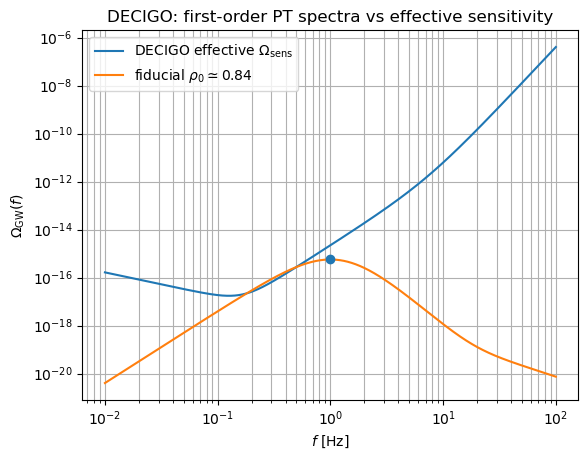

In [4]:
# ============================================================
# Example usage: plug your fiducials here
# (replace Tstar_GeV as appropriate for each rho case)
# ============================================================

fiducials = [
    dict(
        label=r"fiducial $\rho_0\simeq 0.84$",

        # alpha=0.016909143917492195,
        # alpha = 0.010,
        alpha = 0.009,
        beta_over_H=300.0,
        Tstar_GeV=4.295e4,   # <-- use your DECIGO-tuned value
        vw=0.8,
        annotate_peak=False,
    ),
    # Add more fiducials here if you want overlays, e.g. rho~1.27 and rho~0.84:
    # dict(label=r"fiducial $\rho_0\simeq 1.27$", alpha=..., beta_over_H=300.0, Tstar_GeV=4.295e4, vw=0.8),
    # dict(label=r"fiducial $\rho_0\simeq 0.84$", alpha=..., beta_over_H=300.0, Tstar_GeV=4.295e4, vw=0.8),
]

plot_figure_A_decigo(
    fiducials,
    T_obs_yr=4.0,
    n_channels=2,
    fmin=1e-2,
    fmax=1e2,
    nplot=4000,
    show_h2=False,  # set True if you want h^2 * Omega
    title="DECIGO: first-order PT spectra vs effective sensitivity",
)

# Ellipse plots

## Fisher matrices for the DECIGO fiducial models

Evaluates the two-parameter Fisher matrix for the three DECIGO fiducial models used in the ellipse plot. The fixed parameters are $\beta/H_* = 300, T_* = 4.295\times 10^4~{\rm GeV}, v_w = 0.8$
while the transition strength $\alpha$ is varied to produce fiducials with different signal-to-noise ratios.

The results are stored in `fisher_results`

In [5]:
# ============================================================
# Compute Fisher outputs for the three DECIGO fiducials
# ============================================================

beta_over_H_star = 300.0
Tstar_star = 4.295e4
vw_star = 0.8

decigo_fiducials = [
    (0.016909143917492195, r"$\rho_0 = 10$"),
    (0.010,               r"$\rho_0 \simeq 1.27$"),
    (0.009,               r"$\rho_0 \simeq 0.87$"),
]

fisher_results = []

for alpha_star, label in decigo_fiducials:
    ln_alpha0 = np.log(alpha_star)
    ln_beta_over_H0 = np.log(beta_over_H_star)
    ln_Tstar0 = np.log(Tstar_star)
    ln_vw0 = np.log(vw_star)

    F2, cov2, sig2, corr2, rho0 = fisher_decigo_crosscorr_lnparams_2par(
        ln_alpha0=ln_alpha0,
        ln_beta_over_H0=ln_beta_over_H0,
        ln_Tstar0=ln_Tstar0,
        ln_vw0=ln_vw0,
        T_obs_yr=4.0,
        fmin=0.01,
        fmax=100.0,
        nfreq=200000,
        n_channels=2,
        dln=1e-3,
    )

    fisher_results.append({
        "label": label,
        "alpha0": alpha_star,
        "beta0": beta_over_H_star,
        "ln_alpha0": ln_alpha0,
        "ln_beta0": ln_beta_over_H0,
        "cov2": cov2,
        "rho0": rho0,
        "sig2": sig2,
        "corr2": corr2,
    })

    print(label)
    print("  alpha0 =", alpha_star)
    print("  beta/H* =", beta_over_H_star)
    print("  rho0 =", rho0)
    print("  sigmas =", sig2)
    print("  corr =\n", corr2)
    print()

$\rho_0 = 10$
  alpha0 = 0.016909143917492195
  beta/H* = 300.0
  rho0 = 9.999999999999996
  sigmas = [0.118939   0.14526659]
  corr =
 [[1.         0.97658131]
 [0.97658131 1.        ]]

$\rho_0 \simeq 1.27$
  alpha0 = 0.01
  beta/H* = 300.0
  rho0 = 1.2714250102188025
  sigmas = [0.9273092  1.14256338]
  corr =
 [[1.         0.97658208]
 [0.97658208 1.        ]]

$\rho_0 \simeq 0.87$
  alpha0 = 0.009
  beta/H* = 300.0
  rho0 = 0.8390362174318866
  sigmas = [1.40336792 1.73137757]
  corr =
 [[1.         0.97658229]
 [0.97658229 1.        ]]



## Fisher-ellipse and SNR-contour plotting functions

Define helper functions used to visualize the Fisher constraints in the 
$\alpha,\beta/H_*$ plane. The code computes SNR contours over a grid of 
$\alpha$ and $\beta/H_*$, converts the covariance matrices from logarithmic 
parameter space into ellipses in physical parameter space, and provides a plotting 
routine for each panel.

The actual SNR grid and final three-panel figure are generated in the next cell.

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

def rho_decigo_for_pt_params(
    *,
    alpha: float,
    beta_over_H: float,
    Tstar_GeV: float,
    vw: float,
    T_obs_yr: float = 4.0,
    fmin: float = 0.01,
    fmax: float = 100.0,
    nfreq: int = 100000,
    n_channels: int = 2,
    gamma_func=None,
    gstar: float = 106.75,
    Uf=None,
    zp: float = 6.9,
    Gamma: float = 4.0 / 3.0,
    turb_fraction: float = 0.05,
) -> float:
    """
    Compute the DECIGO SNR for a phase-transition model.

    This is a lightweight wrapper around snr_decigo_crosscorr_from_params,
    used when building the SNR contour grid in the alpha--beta/H_* plane.
    """
    return snr_decigo_crosscorr_from_params(
        alpha=alpha,
        beta_over_H=beta_over_H,
        Tstar_GeV=Tstar_GeV,
        vw=vw,
        T_obs_yr=T_obs_yr,
        fmin=fmin,
        fmax=fmax,
        nfreq=nfreq,
        n_channels=n_channels,
        gamma_func=gamma_func,
        gstar=gstar,
        Uf=Uf,
        zp=zp,
        Gamma=Gamma,
        turb_fraction=turb_fraction,
    )

def fisher_ellipse_points(cov2, center, nsig=1.0, npts=700):
    cov2 = np.asarray(cov2, dtype=float)
    vals, vecs = np.linalg.eigh(cov2)
    if np.any(vals <= 0):
        raise ValueError("Covariance not positive definite.")
    t = np.linspace(0, 2*np.pi, npts)
    circle = np.vstack([np.cos(t), np.sin(t)])
    L = vecs @ np.diag(np.sqrt(vals))
    pts = np.array(center).reshape(2, 1) + nsig * (L @ circle)
    return pts[0, :], pts[1, :]

def compute_snr_grid_decigo(
    *,
    Tstar_GeV,
    vw,
    beta_range=(3.0, 1.0e4),
    alpha_range=(3e-5, 3.0),
    n_beta=110,
    n_alpha=90,
    T_obs_yr=4.0,
    fmin=0.01,
    fmax=100.0,
    nfreq=100000,
    n_channels=2,
    gamma_func=None,
    gstar=106.75,
    Uf=None,
    zp=6.9,
    Gamma=4.0/3.0,
    turb_fraction=0.05,
):
    betas  = np.logspace(np.log10(beta_range[0]), np.log10(beta_range[1]), int(n_beta))
    alphas = np.logspace(np.log10(alpha_range[0]), np.log10(alpha_range[1]), int(n_alpha))
    R = np.zeros((alphas.size, betas.size), dtype=float)

    for ia, a in enumerate(alphas):
        for ib, b in enumerate(betas):
            R[ia, ib] = rho_decigo_for_pt_params(
                alpha=float(a),
                beta_over_H=float(b),
                Tstar_GeV=Tstar_GeV,
                vw=vw,
                T_obs_yr=T_obs_yr,
                fmin=fmin,
                fmax=fmax,
                nfreq=nfreq,
                n_channels=n_channels,
                gamma_func=gamma_func,
                gstar=gstar,
                Uf=Uf,
                zp=zp,
                Gamma=Gamma,
                turb_fraction=turb_fraction,
            )
    return betas, alphas, R

def plot_decigo_snr_fisher_on_ax(
    ax,
    *,
    betas,
    alphas,
    R,
    cov2,
    ln_alpha0,
    ln_beta0,
    snr_levels=(0.5, 1, 3, 5, 10),
    ellipse_nsigs=(1.0, 2.0),
    panel_title="",
    snr_alpha=0.7,
    fill_2s_alpha=0.5,
    fill_1s_alpha=0.9,
):
    B, A = np.meshgrid(betas, alphas)

    fill_2s = "#FCA5A5"
    fill_1s = "#93C5FD"

    if 2.0 in ellipse_nsigs:
        xln, yln = fisher_ellipse_points(cov2, center=(ln_alpha0, ln_beta0), nsig=2.0, npts=1200)
        a2 = np.exp(xln)
        b2 = np.exp(yln)
        ax.fill(b2, a2, color=fill_2s, alpha=fill_2s_alpha, zorder=1)
        ax.plot(b2, a2, color="k", linewidth=1.4, zorder=2)

    if 1.0 in ellipse_nsigs:
        xln, yln = fisher_ellipse_points(cov2, center=(ln_alpha0, ln_beta0), nsig=1.0, npts=1200)
        a1 = np.exp(xln)
        b1 = np.exp(yln)
        ax.fill(b1, a1, color=fill_1s, alpha=fill_1s_alpha, zorder=2)
        ax.plot(b1, a1, color="k", linewidth=1.4, zorder=3)

    ax.scatter([np.exp(ln_beta0)], [np.exp(ln_alpha0)],
               s=55, edgecolors="k", linewidths=0.8, zorder=7)

    colors = ("#4C1D95", "#1D4ED8", "#059669", "#DC2626", "#111827")
    ax.contour(
        B, A, R,
        levels=list(snr_levels),
        colors=colors,
        linestyles=["--"] * len(snr_levels),
        linewidths=[1.6] * len(snr_levels),
        alpha=snr_alpha,
        zorder=4
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(betas[0], betas[-1])
    ax.set_ylim(alphas[0], alphas[-1])
    ax.set_title(panel_title)
    ax.grid(True, which="major", alpha=0.20)
    ax.grid(False, which="minor")




## DECIGO SNR contours and Fisher ellipses

Builds the SNR grid at fixed 
$T_* = 4.295\times 10^4~{\rm GeV}, v_w = 0.8$
and overlays the Fisher ellipses for the three DECIGO fiducial models computed above.
The resulting figure compares how the Fisher constraints scale as the fiducial SNR is lowered.

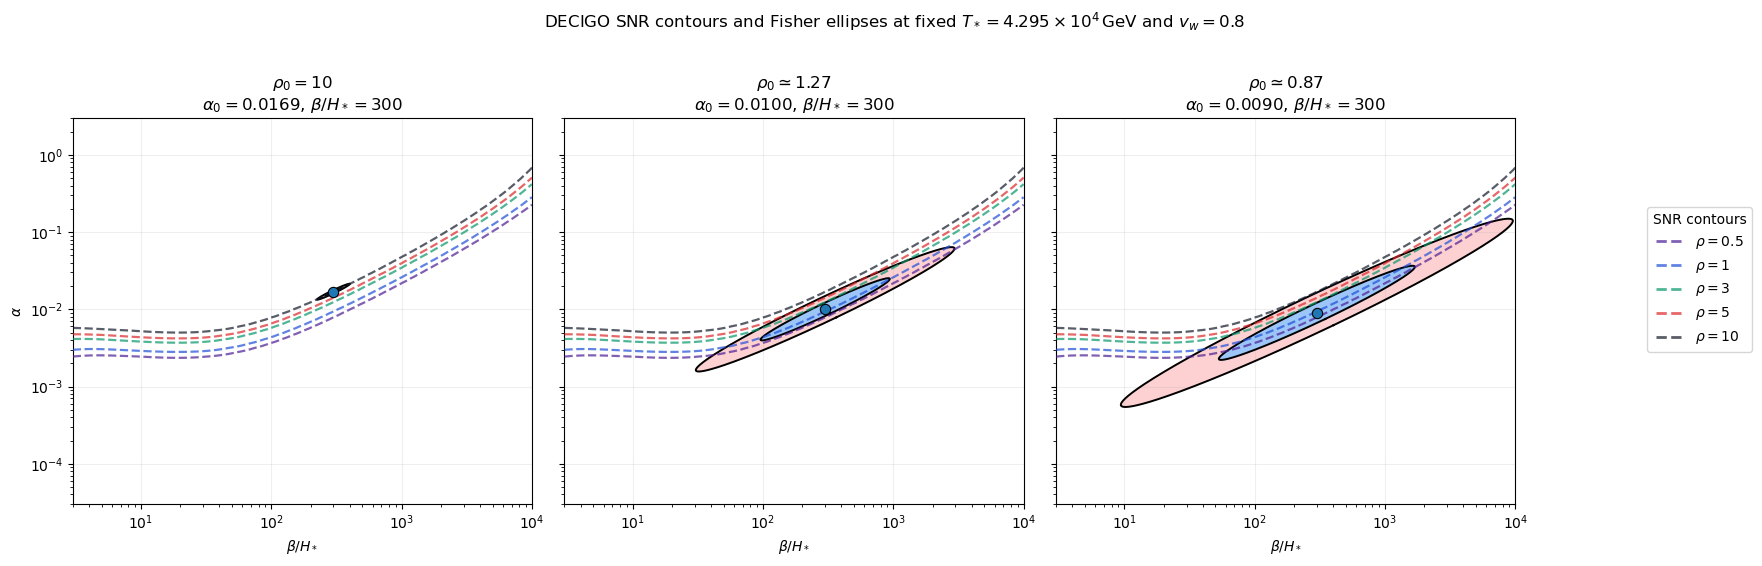

In [7]:
# Build SNR grid
# ------------------------------------------------------------
Tstar_fix = 4.295e4
vw_fix = 0.8

betas, alphas, R = compute_snr_grid_decigo(
    Tstar_GeV=Tstar_fix,
    vw=vw_fix,
    beta_range=(3.0, 1.0e4),
    alpha_range=(3e-5, 3.0),
    n_beta=110,
    n_alpha=90,
    T_obs_yr=4.0,
    fmin=0.01,
    fmax=100.0,
    nfreq=100000,
    n_channels=2,
)

# ------------------------------------------------------------
# Plot all three Fisher ellipses
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)

for ax, res in zip(axes, fisher_results):
    panel_title = res["label"] + "\n" + rf"$\alpha_0={res['alpha0']:.4f}$, $\beta/H_*=300$"

    plot_decigo_snr_fisher_on_ax(
        ax,
        betas=betas,
        alphas=alphas,
        R=R,
        cov2=res["cov2"],
        ln_alpha0=res["ln_alpha0"],
        ln_beta0=res["ln_beta0"],
        snr_levels=(0.5, 1, 3, 5, 10),
        ellipse_nsigs=(1.0, 2.0),
        panel_title=panel_title,
        snr_alpha=0.7,
        fill_2s_alpha=0.5,
        fill_1s_alpha=0.9,
    )

axes[0].set_ylabel(r"$\alpha$")
for ax in axes:
    ax.set_xlabel(r"$\beta/H_*$")

snr_levels = (0.5, 1, 3, 5, 10)
colors = ("#4C1D95", "#1D4ED8", "#059669", "#DC2626", "#111827")
snr_handles = [
    Line2D([0], [0], color=c, lw=2.0, alpha=0.7, linestyle="--", label=rf"$\rho={lvl:g}$")
    for c, lvl in zip(colors, snr_levels)
]
fisher_handles = [
    Line2D([0], [0], color="k", lw=8, alpha=0.5, label=r"$2\sigma$ Fisher"),
    Line2D([0], [0], color="k", lw=8, alpha=0.9, label=r"$1\sigma$ Fisher"),
]

fig.legend(handles=snr_handles, loc="center right", bbox_to_anchor=(0.98, 0.53), frameon=True, title="SNR contours")

fig.suptitle(
    r"DECIGO SNR contours and Fisher ellipses at fixed $T_*=4.295\times10^4\,{\rm GeV}$ and $v_w=0.8$",
    y=1.02
)
fig.tight_layout(rect=[0, 0, 0.86, 1])
#plt.savefig("decigo_fisher_compare_3panel.png", dpi=300, bbox_inches="tight")
plt.show()